# Sensor Low-Peak Timestamp Extraction

This notebook reads two sensor CSV files, computes accelerometer magnitude for each one, detects sharp low peaks, and writes the detected timestamps to a combined CSV.

In [7]:
from pathlib import Path
import csv
import datetime as dt
import math
import statistics

INPUT_CSVS = [
    Path("../data/sensor_data_20260516_225339.csv"),
    Path("../data/sensor_data_20260516_225343.csv"),
]
OUTPUT_CSV = Path("../results/sensor_low_peaks.csv")

SMOOTH_WINDOW = 5
MIN_INTERVAL_MS = 140
PROMINENCE_MIN = 0.10
LOW_PEAK_FLOOR = 0.20
MERGE_GAP_MS = 120

In [8]:
def moving_average(values: list[float], window: int) -> list[float]:
    if window <= 1 or not values:
        return values[:]

    out: list[float] = []
    running = 0.0
    queue: list[float] = []

    for value in values:
        queue.append(value)
        running += value
        if len(queue) > window:
            running -= queue.pop(0)
        out.append(running / len(queue))

    return out


def robust_low_threshold(values: list[float], floor: float = LOW_PEAK_FLOOR) -> float:
    if not values:
        return floor

    median = statistics.median(values)
    deviations = [abs(value - median) for value in values]
    mad = statistics.median(deviations)
    return median - max(floor, 1.5 * mad)


def ms_to_iso8601(timestamp_ms: int) -> str:
    return dt.datetime.fromtimestamp(timestamp_ms / 1000.0, tz=dt.timezone.utc).isoformat()


def load_accelerometer_samples(path: Path) -> tuple[list[int], list[float]]:
    timestamps: list[int] = []
    magnitudes: list[float] = []

    with path.open("r", newline="") as file:
        reader = csv.DictReader(file)
        for row in reader:
            if row.get("sensor") != "Accelerometer":
                continue
            timestamp_ms = int(row["timestamp"])
            x = float(row["x"])
            y = float(row["y"])
            z = float(row["z"])
            magnitude = math.sqrt(x * x + y * y + z * z)
            timestamps.append(timestamp_ms)
            magnitudes.append(magnitude)

    return timestamps, magnitudes


def detect_sharp_low_peaks(
    timestamps_ms: list[int],
    magnitudes: list[float],
    smooth_window: int = SMOOTH_WINDOW,
    min_interval_ms: int = MIN_INTERVAL_MS,
    prominence_min: float = PROMINENCE_MIN,
) -> list[int]:
    if len(timestamps_ms) < 3:
        return []

    signal = moving_average(magnitudes, smooth_window)
    threshold = robust_low_threshold(signal)

    peak_indices: list[int] = []
    last_ts = -10**18

    for i in range(1, len(signal) - 1):
        center = signal[i]
        if center > threshold:
            continue
        if not (center < signal[i - 1] and center <= signal[i + 1]):
            continue

        left = max(signal[max(0, i - 3):i])
        right = max(signal[i + 1:min(len(signal), i + 4)])
        prominence = min(left, right) - center
        if prominence < prominence_min:
            continue

        timestamp_ms = timestamps_ms[i]
        if timestamp_ms - last_ts < min_interval_ms:
            continue

        peak_indices.append(i)
        last_ts = timestamp_ms

    return [timestamps_ms[index] for index in peak_indices]


def merge_peak_streams(streams: list[tuple[str, list[int]]], merge_gap_ms: int) -> list[dict[str, object]]:
    flat: list[tuple[int, str]] = []
    for source, timestamps in streams:
        for timestamp_ms in timestamps:
            flat.append((timestamp_ms, source))

    flat.sort(key=lambda item: item[0])
    merged: list[dict[str, object]] = []

    for timestamp_ms, source in flat:
        if not merged:
            merged.append({"timestamp_ms": timestamp_ms, "sources": [source]})
            continue

        previous = merged[-1]
        if timestamp_ms - previous["timestamp_ms"] <= merge_gap_ms:
            if source not in previous["sources"]:
                previous["sources"].append(source)
            continue

        merged.append({"timestamp_ms": timestamp_ms, "sources": [source]})

    return merged

In [9]:
per_file_peaks: list[tuple[str, list[int]]] = []

for csv_path in INPUT_CSVS:
    timestamps_ms, magnitudes = load_accelerometer_samples(csv_path)
    peaks = detect_sharp_low_peaks(timestamps_ms, magnitudes)
    per_file_peaks.append((csv_path.name, peaks))

merged_peaks = merge_peak_streams(per_file_peaks, MERGE_GAP_MS)

rows: list[dict[str, object]] = []
for index, event in enumerate(merged_peaks, start=1):
    rows.append(
        {
            "peak_number": index,
            "timestamp_ms": event["timestamp_ms"],
            "timestamp_utc": ms_to_iso8601(event["timestamp_ms"]),
            "sources": ";".join(event["sources"]),
        }
    )

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
with OUTPUT_CSV.open("w", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=["peak_number", "timestamp_ms", "timestamp_utc", "sources"])
    writer.writeheader()
    writer.writerows(rows)

print(f"Processed files: {len(INPUT_CSVS)}")
for source, peaks in per_file_peaks:
    print(f"Peaks in {source}: {len(peaks)}")
print(f"Merged peaks: {len(rows)}")
print(f"Saved combined peak timestamps to: {OUTPUT_CSV}")

rows[:5]

Processed files: 2
Peaks in sensor_data_20260516_225339.csv: 195
Peaks in sensor_data_20260516_225343.csv: 35
Merged peaks: 228
Saved combined peak timestamps to: ../results/sensor_low_peaks.csv


[{'peak_number': 1,
  'timestamp_ms': 1778964581293,
  'timestamp_utc': '2026-05-16T20:49:41.293000+00:00',
  'sources': 'sensor_data_20260516_225339.csv;sensor_data_20260516_225343.csv'},
 {'peak_number': 2,
  'timestamp_ms': 1778964582503,
  'timestamp_utc': '2026-05-16T20:49:42.503000+00:00',
  'sources': 'sensor_data_20260516_225343.csv'},
 {'peak_number': 3,
  'timestamp_ms': 1778964583562,
  'timestamp_utc': '2026-05-16T20:49:43.562000+00:00',
  'sources': 'sensor_data_20260516_225343.csv'},
 {'peak_number': 4,
  'timestamp_ms': 1778964585821,
  'timestamp_utc': '2026-05-16T20:49:45.821000+00:00',
  'sources': 'sensor_data_20260516_225339.csv'},
 {'peak_number': 5,
  'timestamp_ms': 1778964586065,
  'timestamp_utc': '2026-05-16T20:49:46.065000+00:00',
  'sources': 'sensor_data_20260516_225343.csv'}]

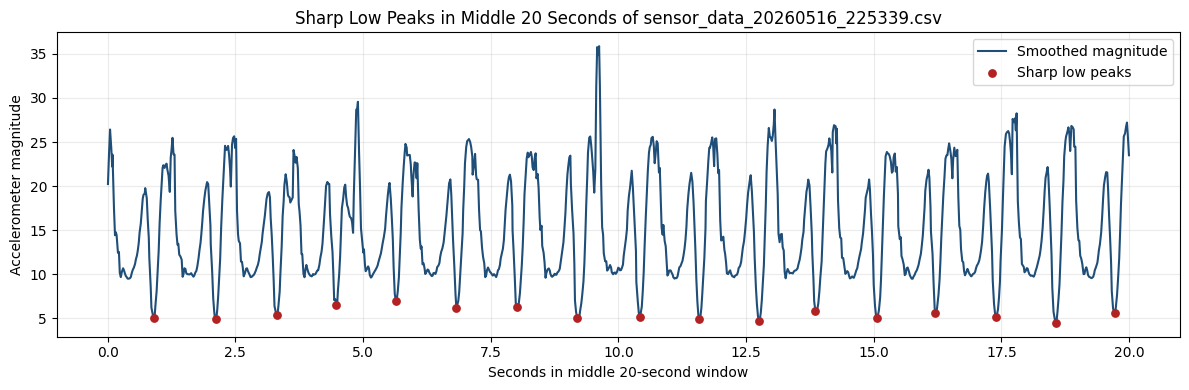

Saved plot to: ../results/sensor_data_20260516_225339_low_peaks_mid20s.png


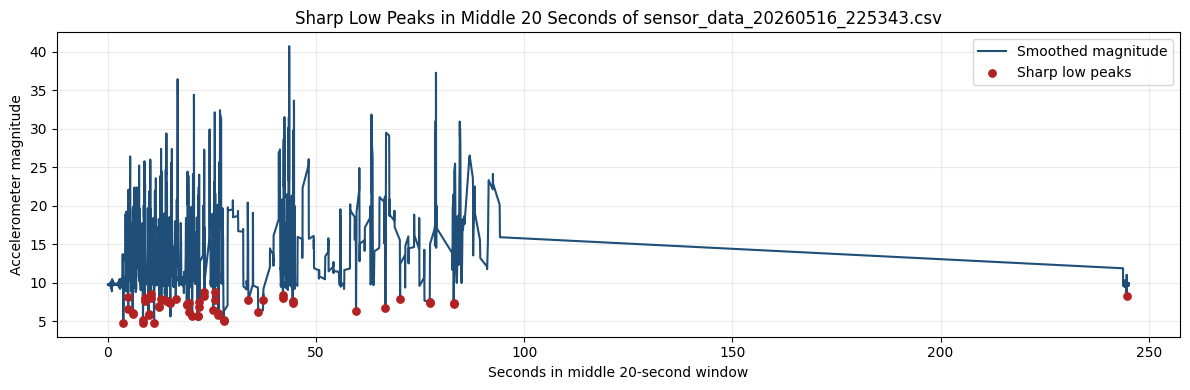

Saved plot to: ../results/sensor_data_20260516_225343_low_peaks_mid20s.png


In [10]:
import matplotlib.pyplot as plt

for source_name, peak_timestamps in per_file_peaks:
    csv_path = next(path for path in INPUT_CSVS if path.name == source_name)
    timestamps_ms, magnitudes = load_accelerometer_samples(csv_path)
    signal = moving_average(magnitudes, SMOOTH_WINDOW)
    peak_set = set(peak_timestamps)

    first_timestamp_ms = timestamps_ms[0]
    last_timestamp_ms = timestamps_ms[-1]
    middle_timestamp_ms = (first_timestamp_ms + last_timestamp_ms) / 2
    window_half_ms = 10_000
    window_start_ms = middle_timestamp_ms - window_half_ms
    window_end_ms = middle_timestamp_ms + window_half_ms

    window_samples = [
        (timestamp_ms, magnitude, smoothed)
        for timestamp_ms, magnitude, smoothed in zip(timestamps_ms, magnitudes, signal)
        if window_start_ms <= timestamp_ms <= window_end_ms
    ]
    if len(window_samples) < 2:
        window_samples = list(zip(timestamps_ms, magnitudes, signal))
        window_start_ms = window_samples[0][0]

    x_seconds = [(timestamp_ms - window_start_ms) / 1000.0 for timestamp_ms, _, _ in window_samples]
    smoothed_values = [smoothed for _, _, smoothed in window_samples]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x_seconds, smoothed_values, color="#1f4e79", linewidth=1.5, label="Smoothed magnitude")

    peak_x = []
    peak_y = []
    for timestamp_ms, _, smoothed in window_samples:
        if timestamp_ms in peak_set:
            peak_x.append((timestamp_ms - window_start_ms) / 1000.0)
            peak_y.append(smoothed)

    if peak_x:
        ax.scatter(peak_x, peak_y, color="#b22222", s=28, label="Sharp low peaks", zorder=3)

    ax.set_title(f"Sharp Low Peaks in Middle 20 Seconds of {csv_path.name}")
    ax.set_xlabel("Seconds in middle 20-second window")
    ax.set_ylabel("Accelerometer magnitude")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()

    plot_path = OUTPUT_CSV.with_name(f"{csv_path.stem}_low_peaks_mid20s.png")
    fig.savefig(plot_path, dpi=160)
    plt.show()
    plt.close(fig)

    print(f"Saved plot to: {plot_path}")

## Output

The notebook writes one row per merged sharp low peak. If both sensor files detect the same peak within the merge gap, they are combined into one output row with both sources listed.